`conda activate r_env`

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    plan("multicore", workers = 8)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

## Li et al. 2023. - https://doi.org/10.1016/j.cell.2023.11.016

In [2]:
load('/projects/0/einf2548/cruiz/dmg/data/references/Li2023/OMIX005437-01.RData')
load('/projects/0/einf2548/cruiz/dmg/data/references/Li2023/OMIX005437-02.RData')

In [3]:
reference <- merge(astro_scrna_obj, c(cere_rg,cor_rg,cs_neural_tube,dien_rg,mid_rg,
                                      npc_scrna_obj,opc_scrna_obj,sub_obj_gluta_1_4),
                  merge.data=FALSE)
reference

Warning message in CheckDuplicateCellNames(object.list = objects):
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


An object of class Seurat 
36601 features across 74538 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

In [4]:
reference <- reference %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()%>%RunUMAP(dims=1:20, return.model = TRUE)

Centering and scaling data matrix

PC_ 1 
Positive:  NEUROD2, NEUROD6, TBR1, SLA, RTN1, MYT1L, STMN2, NSG2, MAPT, NSG1 
	   SYT1, SH3BP5, PPP2R2B, SEZ6, EEF1A2, PCSK1N, RAB3A, RBFOX1, PRDM8, BCL11B 
	   CNTNAP2, GRIA2, ZBTB18, SLC17A7, CTTNBP2, LRRC7, SOX5, DCX, SCG5, DOK6 
Negative:  HMGB2, NUSAP1, TOP2A, MKI67, CENPF, MAD2L1, HMGN2, SMC4, UBE2C, H2AFX 
	   CDK1, PTTG1, TPX2, ASPM, NUF2, BIRC5, CKS2, PBK, PRC1, CKS1B 
	   CCNB2, KIFC1, GTSE1, AURKB, KIF11, PIMREG, MIS18BP1, ANP32E, CCNA2, CKAP2L 
PC_ 2 
Positive:  TUBB3, SOX11, STMN2, MLLT11, BCL11A, ELAVL4, BCL11B, UBE2S, DCX, NEUROD6 
	   TUBA1B, LINC01551, IGFBPL1, NEUROD2, H2AFZ, GAP43, CDKN2D, RTN1, MYT1L, TBR1 
	   HMGB3, ABRACL, UBE2T, ZBTB18, KPNA2, INSM1, NFIB, NSG1, CAMK2N1, TOP2A 
Negative:  PTN, TTYH1, ATP1A2, BCAN, NTRK2, CLU, PON2, METRN, EDNRB, SLC1A3 
	   GPM6B, CSPG5, QKI, SPARCL1, ITM2C, CST3, ATP1B2, ZFP36L1, PLPP3, MT3 
	   SPARC, MGST1, S100B, LUZP2, TNC, PLTP, GRID2, APOE, TIMP3, SOX2 
PC_ 3 
Positive:  VIM, ID4,

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


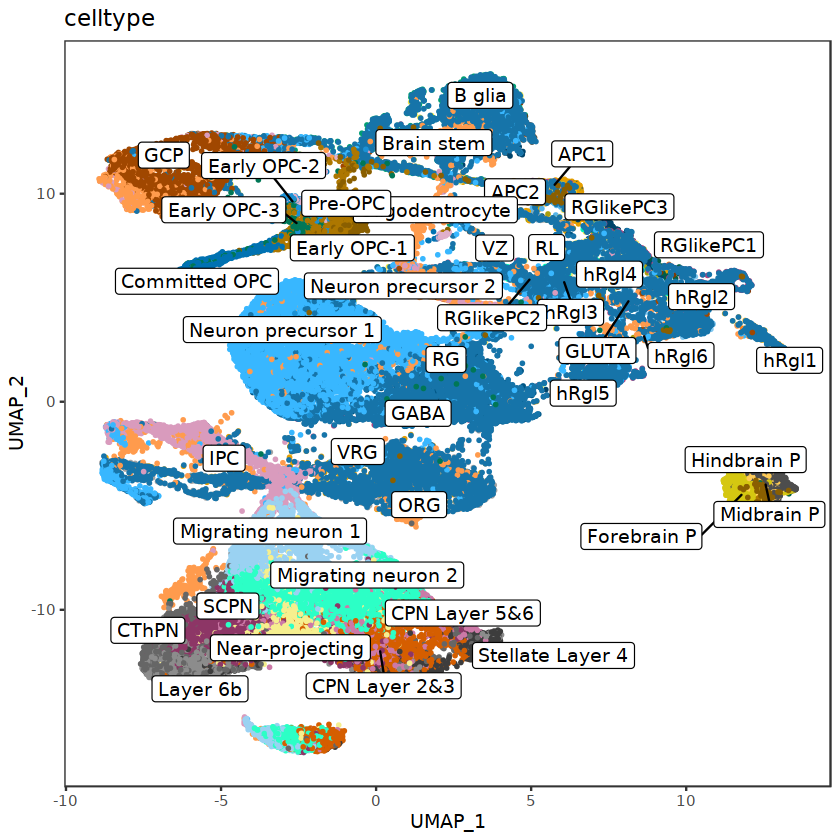

In [5]:
dittoDimPlot(reference, 'celltype',do.label = TRUE, labels.size = 4)+NoLegend()

### Reference mapping

In [6]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
dmg

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [7]:
dmg <- subset(dmg, iCNV == 'tumor')
dmg

An object of class Seurat 
19248 features across 258867 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [8]:
dmg <- dmg %>% NormalizeData()

In [9]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“17353 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 19248 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 6115 anchors

Filtering anchors

	Retained 902 anchors



`Map Query` functions run separately

In [10]:
dmg <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = dmg,
  refdata = list(
      li2023.celltype = 'celltype'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoreli2023.celltype_ to predictionscoreli2023celltype_”


In [14]:
saveRDS(dmg, '../data/predictions/malignant_rna_seurat_predictions_Li2023.rds')

## Wang et al. 2024. - https://doi.org/10.1101/2024.01.16.575956

In [2]:
# RUN ONLY ONCE!!!!!!!!!!!!

sceasy::convertFormat('/projects/0/einf2548/cruiz/dmg/data/references/Wang2024/GEX.h5ad', from="anndata", to="seurat", main_layer = "data",
                       outFile='/projects/0/einf2548/cruiz/dmg/data/references/Wang2024/GEX.rds')

X -> data



An object of class Seurat 
32480 features across 232328 samples within 1 assay 
Active assay: RNA (32480 features, 0 variable features)
 1 layer present: data
 1 dimensional reduction calculated: umap

In [2]:
reference <- readRDS('/projects/0/einf2548/cruiz/dmg/data/references/Wang2024/rna/GEX.rds')
reference

An object of class Seurat 
32480 features across 232328 samples within 1 assay 
Active assay: RNA (32480 features, 0 variable features)
 1 dimensional reduction calculated: umap

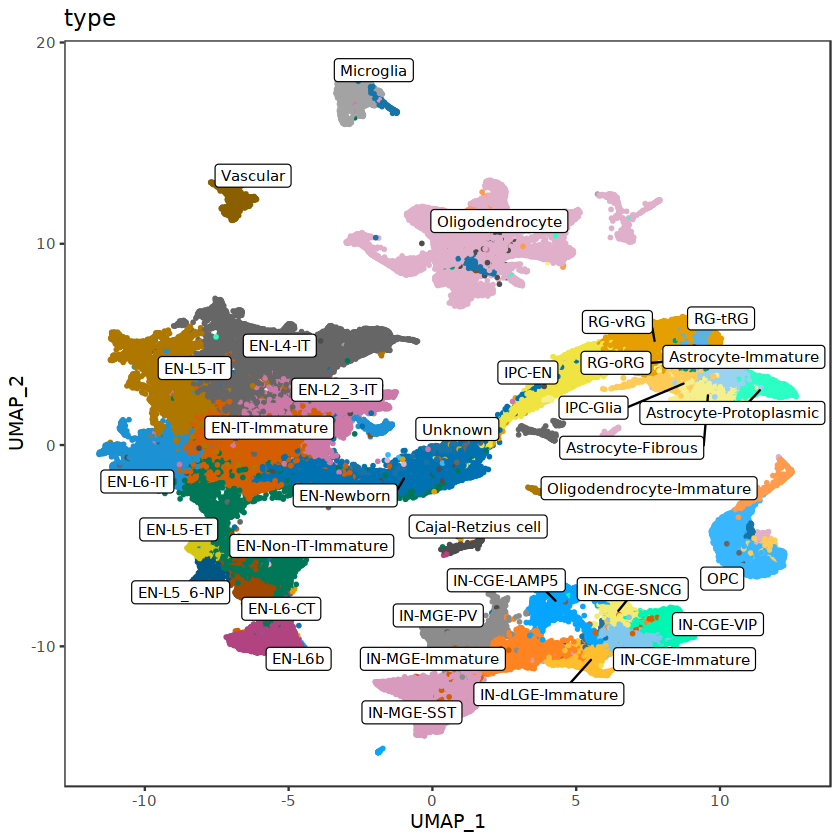

In [3]:
dittoDimPlot(reference, 'type', do.label = TRUE, labels.size = 3)+NoLegend()

In [4]:
reference <- reference%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()

Warning message in FindVariableFeatures.Assay(object = assay.data, selection.method = selection.method, :
“selection.method set to 'vst' but count slot is empty; will use data slot instead”
Centering and scaling data matrix

PC_ 1 
Positive:  MEG3, CSMD1, GRIN2B, DLGAP2, FAM155A, NRG3, FGF14, FGF12, SYT1, KCNIP4 
	   GRM5, RIMS2, FRMPD4, LRFN5, LINGO2, KCNQ5, GRIN2A, RGS7, KCNMA1, STXBP5L 
	   RYR2, CELF2, GABRB2, TENM2, OPCML, AGBL4, RBFOX1, KHDRBS2, CHRM3, GRM7 
Negative:  ST18, QKI, COL4A5, PLP1, ZBTB20, MOBP, TMEM144, DOCK5, RNF220, UGT8 
	   TF, ANLN, ENPP2, FBXL7, C10orf90, PTGDS, MOG, AC012494.1, SLCO1A2, LINC01608 
	   ABCA8, LPAR1, MBP, PPP1R14A, LINC00639, ERBIN, FGFR2, FRMD4B, CLDN11, CNDP1 
PC_ 2 
Positive:  SOX5, SYNE2, SOX11, NFIB, SOX4, IGF2BP2, CASC15, NKAIN3, IGF2BP3, MPPED2 
	   MEIS2, CDON, EZH2, VIM, GLI3, DACH1, PTPRZ1, EPHA5, HBG2, HMGA2 
	   NFIA, EPHA7, FABP7, ROBO2, BCL11B, SLCO5A1, HIST1H4C, LINC01965, AC099792.1, MIR924HG 
Negative:  MAP7, MBP, PLP1, UNC5C, C

### Reference mapping

In [7]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
dmg

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [8]:
dmg <- subset(dmg, iCNV == 'tumor')
dmg

An object of class Seurat 
19248 features across 258867 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [7]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“14328 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 18152 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 12026 anchors

Filtering anchors

	Retained 1264 anchors



`Map Query` functions run separately

In [8]:
dmg <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = dmg,
  refdata = list(
      wang2024.celltype = 'type'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscorewang2024.celltype_ to predictionscorewang2024celltype_”


In [20]:
saveRDS(dmg, '../data/predictions/malignant_rna_seurat_predictions_Wang2024.rds')

## Braun et al. 2022. - https://doi.org/10.1101/2022.10.24.513487

#### Original annotation

In [2]:
reference <- readRDS('../data/references/Braun2023/subset_fetal_brain_atlas_all_genes.rds')
reference

An object of class Seurat 
18675 features across 499781 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 1 dimensional reduction calculated: umap

In [3]:
reference@meta.data

,barcode,CellClass,CellCycle,Clusters,Donor,MitoFraction,NGenes,PrevClusters,SampleID,Sex,Subdivision,Subregion,TopLevelCluster,TotalUMIs,Age,Region
,<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>
10X156_5:CTCATTAAGCGTGTCC,10X156_5:CTCATTAAGCGTGTCC,Radial glia,0.0020885547,127,XDD:334,0.004177109,2419,561,10X156_5,,Midbrain,Midbrain,31,4788,8.0,Midbrain
10X254_5:GCCAGCAGTGGCTTGC,10X254_5:GCCAGCAGTGGCTTGC,Glioblast,0.0094677582,18,XDD:385,0.064355172,3698,506,10X254_5,,Hypothalamus,Hypothalamus,38,7816,14.0,Diencephalon
10X112_1:CAAGTTGCAACACCCG,10X112_1:CAAGTTGCAACACCCG,Neuronal IPC,0.0125599448,69,XHU:305,0.014386847,1919,11,10X112_1,,Forebrain,Forebrain,34,4379,7.5,Forebrain
10X288_1:CGCAGGTAGTGGCGAT,10X288_1:CGCAGGTAGTGGCGAT,Neuron,0.0011734189,406,XDD:395,0.019948123,5114,150,10X288_1,,Brain,Brain,15,16192,6.0,Brain
10X288_6:GTGTGATGTTAGTCGT,10X288_6:GTGTGATGTTAGTCGT,Radial glia,0.0088906502,124,XDD:395,0.027974404,5882,564,10X288_6,,Brain,Brain,31,17659,6.0,Brain
10X188_3:TGTTTGTAGATTGGGC,10X188_3:TGTTTGTAGATTGGGC,Radial glia,0.0408066995,177,XDD:351,0.028541101,3709,390,10X188_3,,Hippocampus,Hippocampus,28,8479,12.0,Telencephalon
10X102_2:AGCGTCGGTTAAAGAC,10X102_2:AGCGTCGGTTAAAGAC,Neuroblast,0.0013852548,296,XHU:297,0.012929044,2540,356,10X102_2,,Cortex,Cortex,1,6497,10.0,Telencephalon
10X112_2:CAGATCAAGCTCCTCT,10X112_2:CAGATCAAGCTCCTCT,Radial glia,0.0050801095,165,XHU:305,0.011918718,2456,372,10X112_2,,Forebrain,Forebrain,29,5118,7.5,Forebrain
10X99_5:CAGCTAAGTCCATGAT,10X99_5:CAGCTAAGTCCATGAT,Neuron,0.0010366275,585,BRC2021,0.004837595,1584,20,10X99_5,,Thalamus,Thalamus,13,2894,8.0,Diencephalon


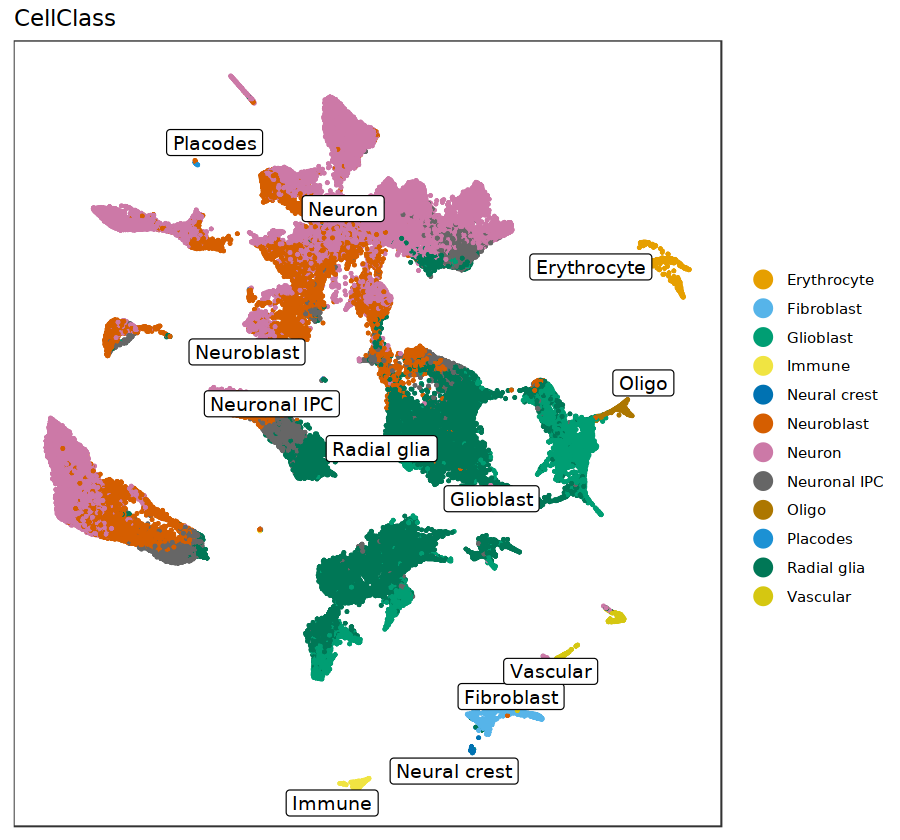

In [4]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(subset(reference, cells = sample(Cells(reference), 100000)),
             reduction.use = "umap", var = "CellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [5]:
table(reference$CellClass)


 Erythrocyte   Fibroblast    Glioblast       Immune Neural crest   Neuroblast 
        2677         5737        39446         2492          264        85476 
      Neuron Neuronal IPC        Oligo     Placodes  Radial glia     Vascular 
      168852        33361         1844          269       155937         3426 

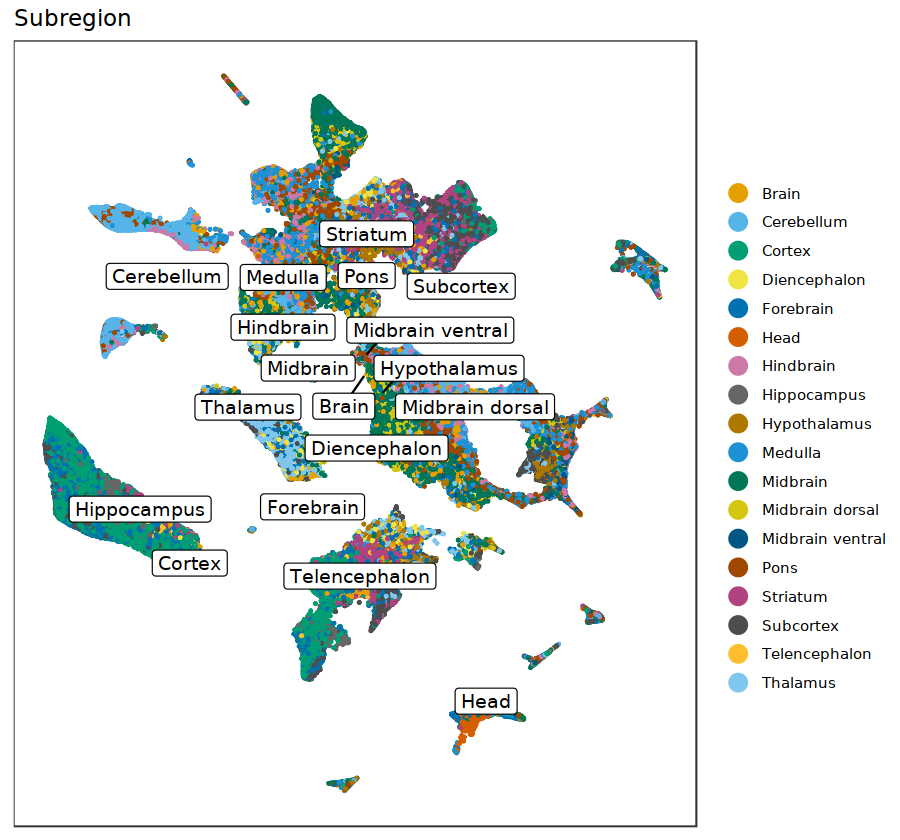

In [6]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(reference,
             reduction.use = "umap", var = "Subregion", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [7]:
reference <- reference %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()

Centering and scaling data matrix

PC_ 1 
Positive:  VIM, HMGB2, ZFP36L1, TOP2A, CENPF, CDK1, SMC4, CKS2, PTTG1, UBE2C 
	   MAD2L1, TPX2, PBK, MKI67, NUF2, BIRC5, CCNA2, ASPM, TTYH1, GTSE1 
	   MIS18BP1, DIAPH3, DLGAP5, APOLD1, NDC80, CENPE, HES1, ECT2, CCNB2, AURKB 
Negative:  STMN2, MYT1L, CTNNA2, NRXN1, CNTNAP2, SYT1, CCSER1, ANK3, LRRC7, GRIA2 
	   FAM155A, RBFOX1, PTPRD, RUNX1T1, CELF4, HECW1, NRG1, DCC, ENOX1, DSCAM 
	   GRIK2, XKR4, SEMA6D, RALYL, KCNB2, AFF3, EPHA5, ATP8A2, PLPPR1, CACNA1E 
PC_ 2 
Positive:  UBE2C, TOP2A, CENPF, CDK1, PBK, HMGB2, PTTG1, BIRC5, CCNA2, MAD2L1 
	   GTSE1, NUF2, TPX2, CDC20, CCNB2, DLGAP5, MKI67, AURKB, CKS2, CCNB1 
	   ASPM, PIMREG, SMC4, PLK1, NDC80, CDCA8, UBE2T, CDCA3, KIFC1, SGO2 
Negative:  S100A11, OLFML3, ARHGAP29, APOE, FCGRT, IFITM2, FOXC1, IGFBP7, EVA1B, COL3A1 
	   IFITM3, COL4A1, DLC1, BGN, COL6A2, FN1, NID1, ETS1, DCN, HLA-E 
	   CEBPD, LAMA4, RCSD1, A2M, COL1A2, TFPI, VAMP5, LGALS1, FOXF2, KLF2 
PC_ 3 
Positive:  FTL, RGS10, TYROBP, 

##### Reference mapping

In [8]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
dmg

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [9]:
dmg <- subset(dmg, iCNV == 'tumor')
dmg

An object of class Seurat 
19248 features across 258867 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [10]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“88 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 18587 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 11013 anchors

Filtering anchors

	Retained 915 anchors



`Map Query` functions run separately

In [11]:
dmg <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = dmg,
  refdata = list(
      braun2023.celltype.original = 'CellClass'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscorebraun2023.celltype.original_ to predictionscorebraun2023celltypeoriginal_”


In [17]:
saveRDS(dmg, '../data/predictions/malignant_rna_seurat_predictions_Braun2023.rds')

#### Detailed annotation

In [2]:
reference <- readRDS('../data/references/Braun2023/subset_fetal_brain_atlas_all_genes.rds')
reference

An object of class Seurat 
18675 features across 499781 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 1 dimensional reduction calculated: umap

In [3]:
reference@meta.data

,barcode,CellClass,CellCycle,Clusters,Donor,MitoFraction,NGenes,PrevClusters,SampleID,Sex,Subdivision,Subregion,TopLevelCluster,TotalUMIs,Age,Region
,<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>
10X156_5:CTCATTAAGCGTGTCC,10X156_5:CTCATTAAGCGTGTCC,Radial glia,0.0020885547,127,XDD:334,0.004177109,2419,561,10X156_5,,Midbrain,Midbrain,31,4788,8.0,Midbrain
10X254_5:GCCAGCAGTGGCTTGC,10X254_5:GCCAGCAGTGGCTTGC,Glioblast,0.0094677582,18,XDD:385,0.064355172,3698,506,10X254_5,,Hypothalamus,Hypothalamus,38,7816,14.0,Diencephalon
10X112_1:CAAGTTGCAACACCCG,10X112_1:CAAGTTGCAACACCCG,Neuronal IPC,0.0125599448,69,XHU:305,0.014386847,1919,11,10X112_1,,Forebrain,Forebrain,34,4379,7.5,Forebrain
10X288_1:CGCAGGTAGTGGCGAT,10X288_1:CGCAGGTAGTGGCGAT,Neuron,0.0011734189,406,XDD:395,0.019948123,5114,150,10X288_1,,Brain,Brain,15,16192,6.0,Brain
10X288_6:GTGTGATGTTAGTCGT,10X288_6:GTGTGATGTTAGTCGT,Radial glia,0.0088906502,124,XDD:395,0.027974404,5882,564,10X288_6,,Brain,Brain,31,17659,6.0,Brain
10X188_3:TGTTTGTAGATTGGGC,10X188_3:TGTTTGTAGATTGGGC,Radial glia,0.0408066995,177,XDD:351,0.028541101,3709,390,10X188_3,,Hippocampus,Hippocampus,28,8479,12.0,Telencephalon
10X102_2:AGCGTCGGTTAAAGAC,10X102_2:AGCGTCGGTTAAAGAC,Neuroblast,0.0013852548,296,XHU:297,0.012929044,2540,356,10X102_2,,Cortex,Cortex,1,6497,10.0,Telencephalon
10X112_2:CAGATCAAGCTCCTCT,10X112_2:CAGATCAAGCTCCTCT,Radial glia,0.0050801095,165,XHU:305,0.011918718,2456,372,10X112_2,,Forebrain,Forebrain,29,5118,7.5,Forebrain
10X99_5:CAGCTAAGTCCATGAT,10X99_5:CAGCTAAGTCCATGAT,Neuron,0.0010366275,585,BRC2021,0.004837595,1584,20,10X99_5,,Thalamus,Thalamus,13,2894,8.0,Diencephalon


In [4]:
colnames(reference@meta.data)

[1] "barcode"         "CellClass"       "CellCycle"       "Clusters"       
 [5] "Donor"           "MitoFraction"    "NGenes"          "PrevClusters"   
 [9] "SampleID"        "Sex"             "Subdivision"     "Subregion"      
[13] "TopLevelCluster" "TotalUMIs"       "Age"             "Region"

In [5]:
table(reference$PrevClusters)


   0   10   11   12   13   14   15   16   17   19   20   21   22   23   24   25 
 741  729 3701 2827 1748 1093 1833 2497  502 1499 1867  518  521 1315  799  499 
  26   27   28   29   31   32   33   34   35   36   37   38   39   40   41   42 
  42  201  793  682 1520  556 1270  665  768 1062  950 1494  658 1065    3   38 
  43   44   45   46   47   48   49   50   51   52   53   54   55   56   57   58 
  35   50   48   20   36    8   31  276  483  139 1134  672 1059  450  365  393 
  59   60   61   62   63   64   65   66   67   68   69   70   71   72   74   75 
1244  332  528  522  279 1129  332  504  722  451  637  368  233  482  799 1923 
  76   77   78   79   80   81   83   85   87   88   89   90   91   92   93   94 
2093  713  545 2273 1292  637  521  496  690  431  603  736  371  329  915  308 
  95   96   97   98   99  100  101  102  103  105  106  107  108  109  110  111 
 412  920 1715  369  207 1714 1353 1665  890  598 1197  600   59   84  281  365 
 112  113  114  115  116  1

In [6]:
detailed_meta <- as.data.frame(fread('../data/references/Braun2023/detailed_annotation_Mossi.csv')) %>% rename('PrevClusters'='PrevCluster')
detailed_meta

V1,ClusterID,CellClass,AnnotationName,AnnotationDescription,AnnotationDefinition,PrevClusters,batch
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
0-0,0,Glioblast,RGL,Radial glia (RGL; +HES1),+HES1,507,0
1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,506,0
2-0,2,Pre-astrocyte,PREAC,Pre-astrocyte (PREAC; +BCAN +TNC +AQP4),+BCAN +TNC +AQP4,515,0
3-0,3,Pre-astrocyte,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,516,0
4-0,4,Glioblast,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,517,0
5-0,5,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,518,0
6-0,6,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,513,0
7-0,7,Pre-astrocyte,O-HEM,Cortical Hem (O-HEM; +CRYAB +RSPO2),+CRYAB +RSPO2,512,0
8-0,8,Pre-astrocyte,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,467,0


In [7]:
meta <- reference@meta.data %>%
  left_join(detailed_meta, by = "PrevClusters")
meta

barcode,CellClass.x,CellCycle,Clusters,Donor,MitoFraction,NGenes,PrevClusters,SampleID,Sex,⋯,TotalUMIs,Age,Region,V1,ClusterID,CellClass.y,AnnotationName,AnnotationDescription,AnnotationDefinition,batch
<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,⋯,<dbl>,<dbl>,<fct>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
10X156_5:CTCATTAAGCGTGTCC,Radial glia,0.0020885547,127,XDD:334,0.004177109,2419,561,10X156_5,,⋯,4788,8.0,Midbrain,102-1,102,Radial glia,S-CC,Cell cycle (S-CC; +TOP2A),+TOP2A,1
10X254_5:GCCAGCAGTGGCTTGC,Glioblast,0.0094677582,18,XDD:385,0.064355172,3698,506,10X254_5,,⋯,7816,14.0,Diencephalon,1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,0
10X112_1:CAAGTTGCAACACCCG,Neuronal IPC,0.0125599448,69,XHU:305,0.014386847,1919,11,10X112_1,,⋯,4379,7.5,Forebrain,21-3,21,Neuronal IPC,NBL,Neuroblast (NBL; +NHLH1),+NHLH1,3
10X288_1:CGCAGGTAGTGGCGAT,Neuron,0.0011734189,406,XDD:395,0.019948123,5114,150,10X288_1,,⋯,16192,6.0,Brain,71-4,71,Neuron,NT-VGLUT2,Glutamatergic 2 (NT-VGLUT2; +SLC17A6),+SLC17A6,4
10X288_6:GTGTGATGTTAGTCGT,Radial glia,0.0088906502,124,XDD:395,0.027974404,5882,564,10X288_6,,⋯,17659,6.0,Brain,99-1,99,Radial glia,RGL,Radial glia (RGL; +HES1),+HES1,1
10X188_3:TGTTTGTAGATTGGGC,Radial glia,0.0408066995,177,XDD:351,0.028541101,3709,390,10X188_3,,⋯,8479,12.0,Telencephalon,6-1,6,Radial glia,S-G2M,Cell cycle G2/M phase (S-G2M; +TOP2A +PLK1),+TOP2A +PLK1,1
10X102_2:AGCGTCGGTTAAAGAC,Neuroblast,0.0013852548,296,XHU:297,0.012929044,2540,356,10X102_2,,⋯,6497,10.0,Telencephalon,9-2,9,Neuroblast,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,2
10X112_2:CAGATCAAGCTCCTCT,Radial glia,0.0050801095,165,XHU:305,0.011918718,2456,372,10X112_2,,⋯,5118,7.5,Forebrain,16-1,16,Radial glia,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,1
10X99_5:CAGCTAAGTCCATGAT,Neuron,0.0010366275,585,BRC2021,0.004837595,1584,20,10X99_5,,⋯,2894,8.0,Diencephalon,78-4,78,Neuron,NEUR,Neuron (NEUR; +INA),+INA,4


In [8]:
reference$DetailedCellClass <- meta$CellClass.y

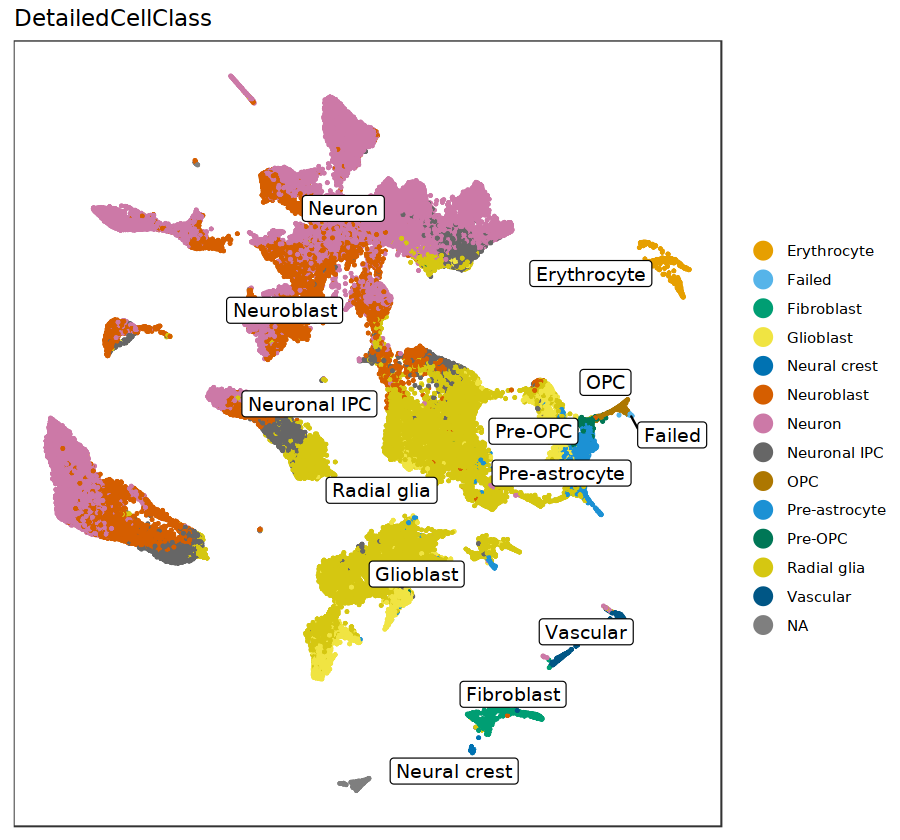

In [9]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(subset(reference, cells = sample(Cells(reference), 100000)),
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [10]:
reference <- subset(reference, CellClass == 'Immune', invert = TRUE)
reference

An object of class Seurat 
18675 features across 497289 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 1 dimensional reduction calculated: umap

In [11]:
reference$DetailedCellClass <- recode(reference$DetailedCellClass,
                                     'Failed'='COP')

In [12]:
table(reference$DetailedCellClass)


          COP   Erythrocyte    Fibroblast     Glioblast  Neural crest 
          207          2677          5737         28094           264 
   Neuroblast        Neuron  Neuronal IPC           OPC Pre-astrocyte 
        85476        168852         33361          1637          9776 
      Pre-OPC   Radial glia      Vascular 
         1576        155937          3426 

In [13]:
reference@meta.data <- reference@meta.data %>%
  mutate(DetailedCellClass = ifelse(is.na(DetailedCellClass), 'NA', as.character(DetailedCellClass)))

In [14]:
reference <- subset(reference, DetailedCellClass == 'NA', invert = TRUE)
reference

An object of class Seurat 
18675 features across 497020 samples within 1 assay 
Active assay: RNA (18675 features, 0 variable features)
 1 dimensional reduction calculated: umap

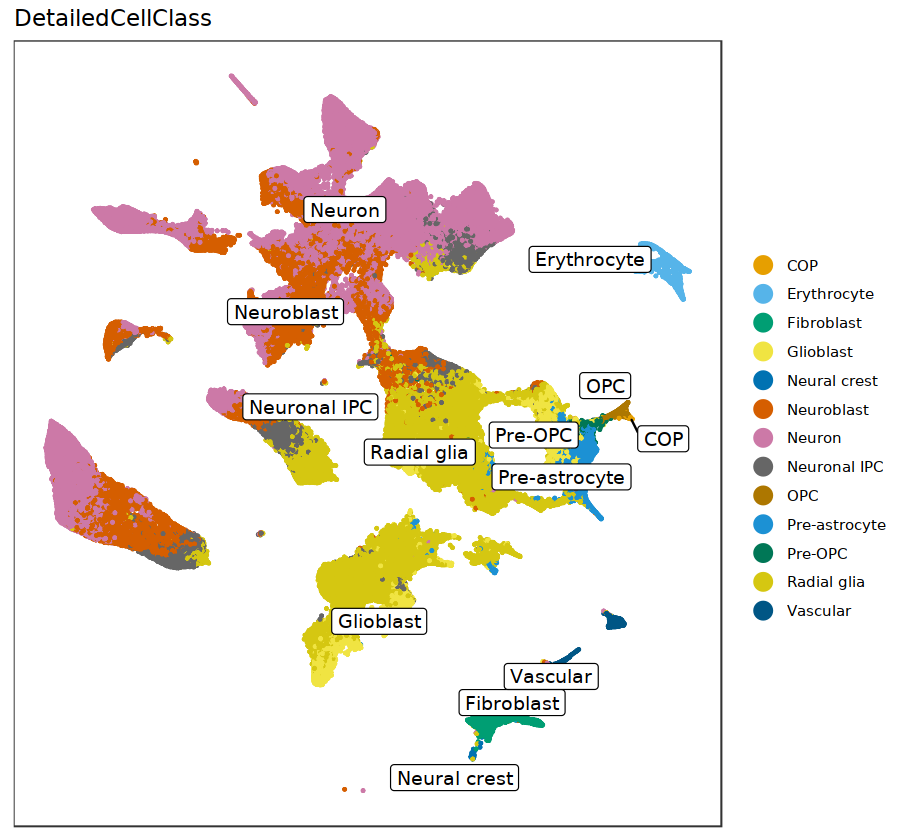

In [15]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(reference,
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

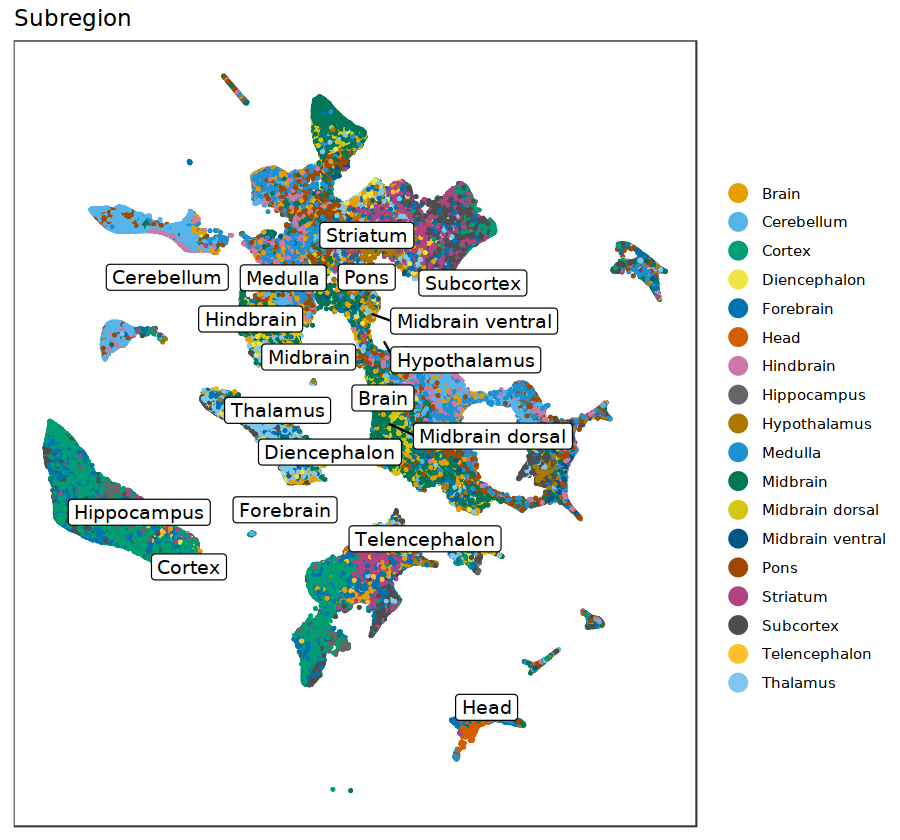

In [16]:
options(repr.plot.height = 7, repr.plot.width = 7.5)
dittoDimPlot(reference,
             reduction.use = "umap", var = "Subregion", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

In [17]:
reference <- reference %>% NormalizeData()%>%FindVariableFeatures()%>%ScaleData()%>%RunPCA()

Centering and scaling data matrix

PC_ 1 
Positive:  VIM, HMGB2, ZFP36L1, TOP2A, CENPF, CDK1, SMC4, CKS2, PTTG1, UBE2C 
	   MAD2L1, PBK, TPX2, MKI67, TTYH1, NUF2, BIRC5, CCNA2, ASPM, GTSE1 
	   DLGAP5, DIAPH3, MIS18BP1, NDC80, APOLD1, HES1, CENPE, ECT2, CCNB2, AURKB 
Negative:  STMN2, MYT1L, CTNNA2, INA, NRXN1, CNTNAP2, CCSER1, SYT1, ANK3, LRRC7 
	   GRIA2, FAM155A, RBFOX1, PTPRD, RUNX1T1, CELF4, HECW1, NRG1, DCC, ENOX1 
	   DSCAM, XKR4, GRIK2, SEMA6D, RALYL, AFF3, KCNB2, DOCK4, EPHA5, ATP8A2 
PC_ 2 
Positive:  UBE2C, TOP2A, CENPF, BIRC5, PTTG1, PBK, CDK1, CCNA2, HMGB2, GTSE1 
	   CDC20, MAD2L1, NUF2, TPX2, CCNB2, AURKB, DLGAP5, CKS2, CCNB1, MKI67 
	   ASPM, NUSAP1, PLK1, PIMREG, CDCA8, NDC80, KPNA2, CDCA3, UBE2T, SGO2 
Negative:  S100A11, ARHGAP29, FOXC1, COL3A1, IFITM3, COL4A1, IGFBP7, DLC1, IFITM2, COL6A2 
	   EVA1B, FN1, BGN, OLFML3, LAMA4, NID1, DCN, COL1A2, TFPI, APOE 
	   ETS1, ITIH5, COLEC12, ATP1A2, EDNRA, VAMP5, FOXF2, COBLL1, CAVIN3, CDC42EP5 
PC_ 3 
Positive:  MDK, ERBB4, C

##### Reference mapping

In [18]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
dmg

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [19]:
dmg <- subset(dmg, iCNV == 'tumor')
dmg

An object of class Seurat 
19248 features across 258867 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [20]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“88 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 18587 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 9937 anchors

Filtering anchors

	Retained 997 anchors



`Map Query` functions run separately

In [21]:
dmg <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = dmg,
  refdata = list(
      braun2023.celltype = 'DetailedCellClass'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscorebraun2023.celltype_ to predictionscorebraun2023celltype_”


In [25]:
saveRDS(dmg, '../data/predictions/malignant_rna_seurat_predictions_Braun2023_detailed.rds')

## Braun et al. 2022. - https://doi.org/10.1101/2022.10.24.513487
## Siletti et al. 2023 - https://doi.org/10.1126/science.add7046
Detailed annotation

In [2]:
fetal <- readRDS('../data/subset_fetal_brain_atlas.rds')
fetal

An object of class Seurat 
3005 features across 832968 samples within 1 assay 
Active assay: RNA (3005 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [3]:
detailed_meta <- as.data.frame(fread('../data/detailed_annotation_Mossi.csv')) %>% rename('PrevClusters'='PrevCluster')
detailed_meta

V1,ClusterID,CellClass,AnnotationName,AnnotationDescription,AnnotationDefinition,PrevClusters,batch
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
0-0,0,Glioblast,RGL,Radial glia (RGL; +HES1),+HES1,507,0
1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,506,0
2-0,2,Pre-astrocyte,PREAC,Pre-astrocyte (PREAC; +BCAN +TNC +AQP4),+BCAN +TNC +AQP4,515,0
3-0,3,Pre-astrocyte,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,516,0
4-0,4,Glioblast,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,517,0
5-0,5,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,518,0
6-0,6,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,513,0
7-0,7,Pre-astrocyte,O-HEM,Cortical Hem (O-HEM; +CRYAB +RSPO2),+CRYAB +RSPO2,512,0
8-0,8,Pre-astrocyte,GBL,Glioblast (GBL; +BCAN +TNC),+BCAN +TNC,467,0


In [4]:
meta <- fetal@meta.data %>%
  left_join(detailed_meta, by = "PrevClusters")
meta

orig.ident,nCount_RNA,nFeature_RNA,barcode,CellClass.x,CellCycle,Clusters,Donor,MitoFraction,NGenes,⋯,Region,RNA_snn_res.0.8,seurat_clusters,V1,ClusterID,CellClass.y,AnnotationName,AnnotationDescription,AnnotationDefinition,batch
<fct>,<dbl>,<int>,<chr>,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,⋯,<fct>,<fct>,<fct>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
10X156,868,317,10X156_5:CTCATTAAGCGTGTCC,Radial glia,0.0020885547,127,XDD:334,0.004177109,2419,⋯,Midbrain,3,3,102-1,102,Radial glia,S-CC,Cell cycle (S-CC; +TOP2A),+TOP2A,1
10X254,2164,566,10X254_5:GCCAGCAGTGGCTTGC,Glioblast,0.0094677582,18,XDD:385,0.064355172,3698,⋯,Diencephalon,17,17,1-0,1,Pre-astrocyte,RGL,Radial glia (RGL; +HES1),+HES1,0
10X112,775,248,10X112_1:CAAGTTGCAACACCCG,Neuronal IPC,0.0125599448,69,XHU:305,0.014386847,1919,⋯,Forebrain,13,13,21-3,21,Neuronal IPC,NBL,Neuroblast (NBL; +NHLH1),+NHLH1,3
10X288,4019,622,10X288_1:CGCAGGTAGTGGCGAT,Neuron,0.0011734189,406,XDD:395,0.019948123,5114,⋯,Brain,6,6,71-4,71,Neuron,NT-VGLUT2,Glutamatergic 2 (NT-VGLUT2; +SLC17A6),+SLC17A6,4
10X288,3689,698,10X288_6:GTGTGATGTTAGTCGT,Radial glia,0.0088906502,124,XDD:395,0.027974404,5882,⋯,Brain,14,14,99-1,99,Radial glia,RGL,Radial glia (RGL; +HES1),+HES1,1
10X188,2031,493,10X188_3:TGTTTGTAGATTGGGC,Radial glia,0.0408066995,177,XDD:351,0.028541101,3709,⋯,Telencephalon,23,23,6-1,6,Radial glia,S-G2M,Cell cycle G2/M phase (S-G2M; +TOP2A +PLK1),+TOP2A +PLK1,1
10X102,1757,371,10X102_2:AGCGTCGGTTAAAGAC,Neuroblast,0.0013852548,296,XHU:297,0.012929044,2540,⋯,Telencephalon,8,8,9-2,9,Neuroblast,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,2
10X112,906,320,10X112_2:CAGATCAAGCTCCTCT,Radial glia,0.0050801095,165,XHU:305,0.011918718,2456,⋯,Forebrain,4,4,16-1,16,Radial glia,P-TEL,Embryonic telencephalon (P-TEL; +FOXG1),+FOXG1,1
10X99,768,276,10X99_5:CAGCTAAGTCCATGAT,Neuron,0.0010366275,585,BRC2021,0.004837595,1584,⋯,Diencephalon,13,13,78-4,78,Neuron,NEUR,Neuron (NEUR; +INA),+INA,4


In [5]:
fetal$DetailedCellClass <- meta$CellClass.y

In [7]:
table(fetal$DetailedCellClass)


  Erythrocyte        Failed    Fibroblast     Glioblast  Neural crest 
         4476           339          9555         46913           416 
   Neuroblast        Neuron  Neuronal IPC           OPC Pre-astrocyte 
       142216        281797         55104          2745         16365 
      Pre-OPC   Radial glia      Vascular 
         2637        260080          5830 

In [8]:
## Gene signature of these cells corresponds to committed oligodendrocyte precursors
fetal$DetailedCellClass <- recode(fetal$DetailedCellClass,
                                     'Failed'='COP')

In [9]:
fetal <- subset(fetal, CellClass %in% c('Immune', 'Erythrocyte', 'Fibroblast', 'Vascular'), 
                    invert = TRUE)
fetal

An object of class Seurat 
3005 features across 809037 samples within 1 assay 
Active assay: RNA (3005 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [10]:
# Define the percentage of cells you want to subset (e.g., 30%)
subset_percentage <- 0.5

# Get the number of cells to subset
num_cells_subset <- round(ncol(fetal) * subset_percentage)

# Randomly sample cell indices
subset_indices <- sample(1:ncol(fetal), num_cells_subset, replace = FALSE)

# Use the subset function to subset the Seurat object
fetal <- subset(fetal, cells = subset_indices)
fetal

An object of class Seurat 
3005 features across 404518 samples within 1 assay 
Active assay: RNA (3005 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [16]:
adult <- readRDS('../data/subset_adult_brain_atlas_with_spinal_cord_and_medulla.rds')
adult

An object of class Seurat 
3000 features across 906470 samples within 1 assay 
Active assay: RNA (3000 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [17]:
# Define the percentage of cells you want to subset (e.g., 30%)
subset_percentage <- 0.2

# Get the number of cells to subset
num_cells_subset <- round(ncol(adult) * subset_percentage)

# Randomly sample cell indices
subset_indices <- sample(1:ncol(adult), num_cells_subset, replace = FALSE)

# Use the subset function to subset the Seurat object
adult <- subset(adult, cells = subset_indices)
adult

An object of class Seurat 
3000 features across 181294 samples within 1 assay 
Active assay: RNA (3000 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [18]:
adult$DetailedCellClass <- adult$Supercluster

In [20]:
reference <- merge(fetal, adult, merge.data = FALSE)
reference

An object of class Seurat 
4702 features across 585602 samples within 1 assay 
Active assay: RNA (4702 features, 0 variable features)

In [21]:
reference <- reference %>% NormalizeData()%>%FindVariableFeatures()%>%
                ScaleData()%>%RunPCA()%>%
                RunUMAP(reduction = 'pca', dims = 1:15, return.model = TRUE)

Centering and scaling data matrix

PC_ 1 
Positive:  FRMPD4, CNTN1, KCNIP4, KCNJ3, FGF14, CDH18, CSMD3, KCND2, GABRB1, MDGA2 
	   SYN2, FGF12, GRM5, CACNA1C, GRM7, KCNC2, MMP16, LINGO2, RBMS3, SIPA1L2 
	   GRIN2B, CALY, ATP8A2, AGBL4, RYR2, CSMD1, OLFM3, KCNH5, CA10, FAM155A 
Negative:  HMGB2, ADGRV1, TUBB4B, KPNA2, HES6, CKS2, PTPRD, DNAJB1, PTTG1, FABP7 
	   TOP2A, CENPF, UBE2C, NAV2, HMGA2, BIRC5, UBE2S, CDK1, TUBA1C, SFRP2 
	   NUF2, CCNB2, TPX2, CCNA2, FGFBP3, MKI67, CACNA2D1, CCN1, FBXL17, DIAPH3 
PC_ 2 
Positive:  MOBP, TMEM144, TF, C10orf90, MBP, MOG, UGT8, DOCK5, SLC44A1, PIP4K2A 
	   BCAS1, ANLN, PLP1, MAN2A1, CNDP1, GAB1, FAM107B, CNP, FOLH1, PTGDS 
	   PLEKHH1, SHROOM4, MAG, LPAR1, CDK18, CARNS1, ATP10B, FA2H, SLC5A11, PHLPP1 
Negative:  SYT1, NRG3, DLGAP1, GRIP1, KALRN, ROBO2, PTPRD, NRG1, SLC44A5, FGF13 
	   ATRNL1, RIMS2, TENM2, FAT3, KCNH7, NRCAM, FAM155A, GPC6, CADPS, PLCB1 
	   TOX, GRIA1, EFNA5, FRMD4A, TUBB4B, SLC8A1, CNTN4, KCNB2, ADGRL2, STXBP5L 
PC_ 3 
Positive: 

In [22]:
rm(fetal)
rm(adult)

gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9804852,523.7,15689827,838.0,15689827,838.0
Vcells,2518942750,19218.1,8273574771,63122.4,8267156797,63073.5


Warning message:
“ggrepel: 22 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


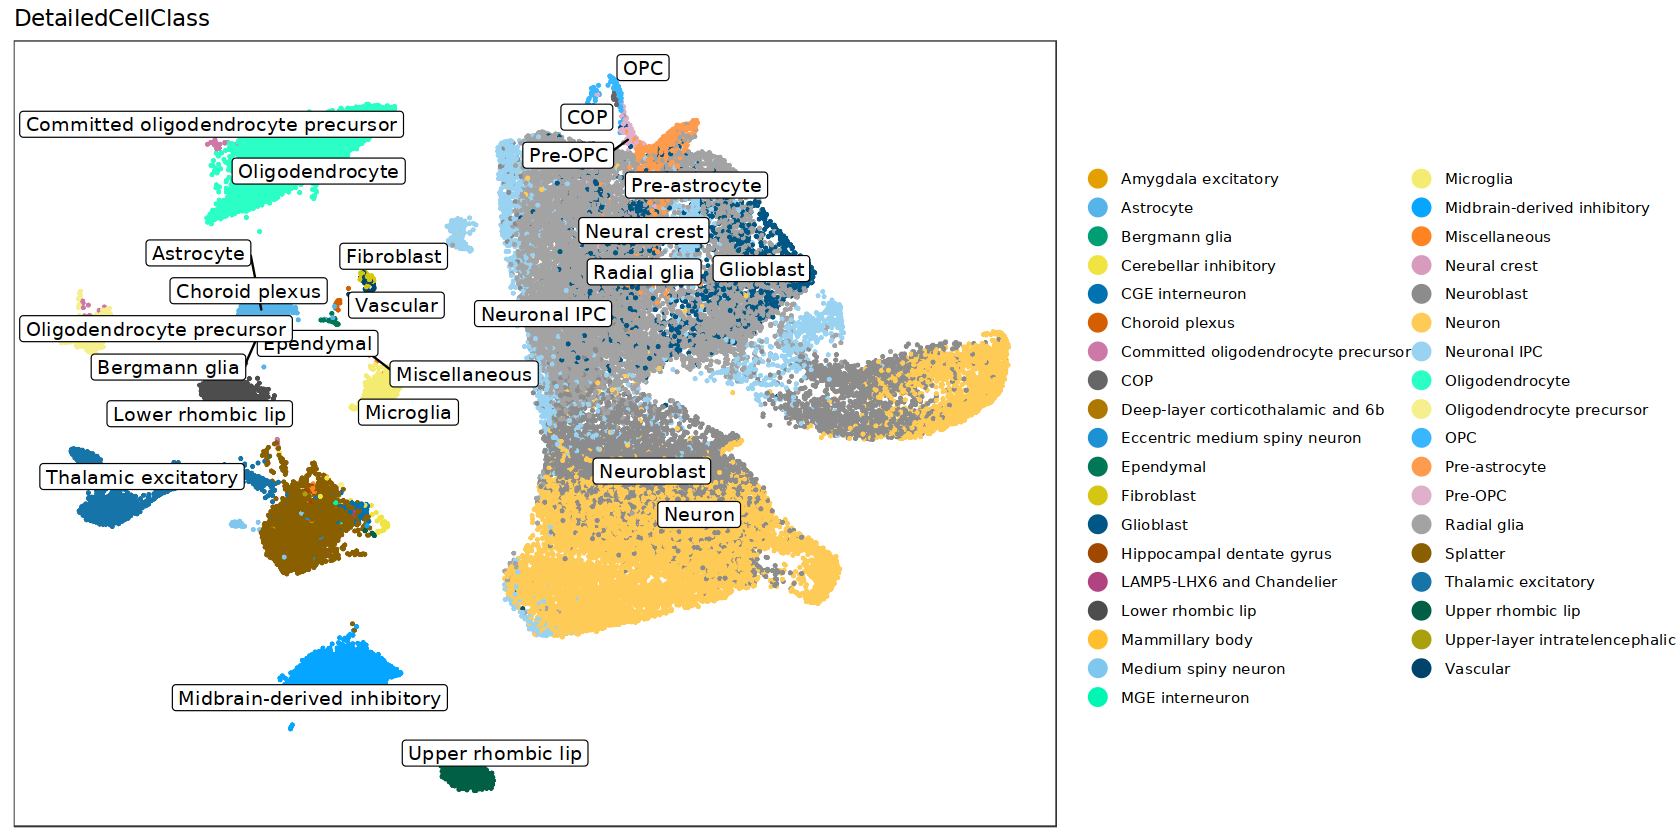

In [23]:
options(repr.plot.height = 7, repr.plot.width = 14)
dittoDimPlot(subset(reference, cells = sample(Cells(reference), 50000)),
             reduction.use = "umap", var = "DetailedCellClass", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 

### Reference mapping glial/malignant

In [24]:
dmg <- readRDS('../data/dmg_compartments/malignant_rna.rds')
dmg

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [28]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“31 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 4671 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 5032 anchors

Filtering anchors

	Retained 858 anchors



`Map Query` functions run separately

In [29]:
dmg <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = dmg,
  refdata = list(
      siletti.DetailedCellClass = 'DetailedCellClass'
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoresiletti.DetailedCellClass_ to predictionscoresilettiDetailedCellClass_”


In [34]:
saveRDS(dmg, 'malignant_rna_seurat_predictions_Braun2023_Siletti2023.rds')

In [26]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.6 (Ootpa)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_env/lib/libopenblasp-r0.3.18.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] data.table_1.14.2  future_1.28.0      dittoSeq_1.9.3     stringr_1.4.1     
 [5] tibble_3.1.8       dplyr_1.0.10       sp_1.5-0           SeuratObject_4.1.0
 [9] Seurat_4.1.1       ggplot2_3.3.6     

loaded via a namespace (and not attached):
  [1] uuid_1.1-0                